# RQ2: Product Clustering and Semantic Clustering (Clean Pipeline)

This notebook answers RQ2 using two approaches:

1. **Track A (Baseline):** TF-IDF + KMeans clustering
2. **Track B (Semantic):** Sentence-BERT embeddings + KMeans clustering

## Outputs
- `rq2_outputs/rq2_tfidf_cluster_summary.csv`
- `rq2_outputs/rq2_tfidf_top_terms.csv`
- `rq2_outputs/rq2_semantic_cluster_summary.csv`
- `rq2_outputs/rq2_semantic_top_terms.csv`
- `rq2_outputs/rq2_elbow_tfidf.png`
- `rq2_outputs/rq2_semantic_scatter.png`

In [11]:
# If needed, run once in your selected kernel
# %pip install -q pandas numpy scikit-learn matplotlib seaborn sentence-transformers umap-learn

In [12]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "rq2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Config
MAX_ROWS = 10000
K_VALUES = list(range(2, 9))
TFIDF_K = 5
SEMANTIC_K = 5

print("Base dir:", BASE_DIR)
print("Output dir:", OUTPUT_DIR)

Base dir: /Users/jainesh/Downloads/Deep Learning/6165 group
Output dir: /Users/jainesh/Downloads/Deep Learning/6165 group/rq2_outputs


In [13]:
# --------- Load data ---------
DATA_CANDIDATES = [
    BASE_DIR / "cleaned_amazon_random_reviews.csv",
    BASE_DIR / "sports_random_50k_final.csv",
    BASE_DIR / "cleaned_amazon_reviews.csv",
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("No input dataset found. Update DATA_CANDIDATES.")

print("Using dataset:", data_path)
df = pd.read_csv(data_path)
if MAX_ROWS is not None:
    df = df.head(MAX_ROWS).copy()

TEXT_COL_CANDIDATES = ["clean_text_final", "clean_text", "text", "review_text", "content"]
PRODUCT_COL_CANDIDATES = ["product_name", "title", "asin", "parent_asin"]

text_col = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
product_col = next((c for c in PRODUCT_COL_CANDIDATES if c in df.columns), None)
if text_col is None:
    raise ValueError(f"No text column found in {TEXT_COL_CANDIDATES}")

if product_col is None:
    df["product_ref"] = "unknown_product"
    product_col = "product_ref"

df[text_col] = df[text_col].fillna("").astype(str)
df[product_col] = df[product_col].fillna("unknown_product").astype(str)

# Keep non-empty text
work_df = df[df[text_col].str.strip() != ""].copy().reset_index(drop=True)
print("Rows used:", len(work_df))
print("Text col:", text_col, "| Product col:", product_col)

Using dataset: /Users/jainesh/Downloads/Deep Learning/6165 group/cleaned_amazon_random_reviews.csv
Rows used: 9998
Text col: clean_text_final | Product col: product_name


TF-IDF shape: (9998, 21042)


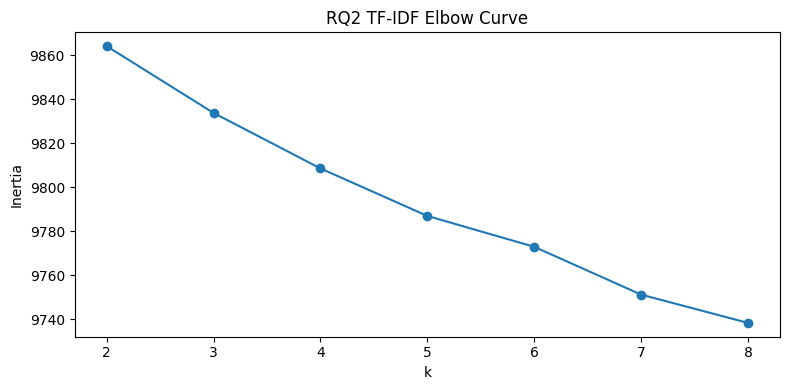

   k      inertia  silhouette
0  2  9864.209812    0.002419
1  3  9833.855035    0.003221
2  4  9808.639098    0.003758
3  5  9787.041322    0.003760
4  6  9773.015032    0.004526
5  7  9751.281830    0.004132
6  8  9738.422375    0.004430


In [14]:
# --------- Track A: TF-IDF + KMeans ---------
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
    sublinear_tf=True,
)

X_tfidf = vectorizer.fit_transform(work_df[text_col])
print("TF-IDF shape:", X_tfidf.shape)

inertias = []
silhouettes = []
for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_tfidf, labels))

plt.figure(figsize=(8, 4))
plt.plot(K_VALUES, inertias, marker="o", label="Inertia")
plt.xticks(K_VALUES)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("RQ2 TF-IDF Elbow Curve")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_elbow_tfidf.png", dpi=150)
plt.show()

print(pd.DataFrame({"k": K_VALUES, "inertia": inertias, "silhouette": silhouettes}))

In [15]:
# Fit selected TF-IDF KMeans and summarize clusters
kmeans_tfidf = KMeans(n_clusters=TFIDF_K, random_state=SEED, n_init=10)
work_df["tfidf_cluster"] = kmeans_tfidf.fit_predict(X_tfidf)

cluster_summary_tfidf = (
    work_df.groupby("tfidf_cluster")
    .agg(
        n_reviews=(text_col, "size"),
        avg_text_len=(text_col, lambda s: float(s.str.len().mean())),
        unique_products=(product_col, pd.Series.nunique),
    )
    .reset_index()
    .sort_values("n_reviews", ascending=False)
)

# Top terms per TF-IDF cluster
feature_names = np.array(vectorizer.get_feature_names_out())
centers = kmeans_tfidf.cluster_centers_
top_rows = []
for cid in range(TFIDF_K):
    top_idx = np.argsort(centers[cid])[-15:][::-1]
    top_terms = ", ".join(feature_names[top_idx])
    top_rows.append({"cluster": cid, "top_terms": top_terms})

top_terms_tfidf = pd.DataFrame(top_rows)

cluster_summary_tfidf.to_csv(OUTPUT_DIR / "rq2_tfidf_cluster_summary.csv", index=False)
top_terms_tfidf.to_csv(OUTPUT_DIR / "rq2_tfidf_top_terms.csv", index=False)

cluster_summary_tfidf

,tfidf_cluster,n_reviews,avg_text_len,unique_products
4,4,6795,133.851067,6163
3,3,992,59.933468,975
2,2,903,56.097453,876
0,0,702,65.467236,696
1,1,606,62.702970,596


In [16]:
# --------- Track B: Semantic embeddings + KMeans ---------
# Fallback strategy:
# 1) Use existing .npy embeddings if row count matches.
# 2) Otherwise compute embeddings using sentence-transformers.

embeddings = None
existing_embedding_candidates = [
    BASE_DIR / "bert_embeddings_10k.npy",
    BASE_DIR / "bert_embeddings_raw_10k.npy",
]

for p in existing_embedding_candidates:
    if p.exists():
        arr = np.load(p)
        if arr.shape[0] == len(work_df):
            embeddings = arr
            print("Using existing embeddings:", p, arr.shape)
            break

if embeddings is None:
    from sentence_transformers import SentenceTransformer

    model_name = "all-MiniLM-L6-v2"
    encoder = SentenceTransformer(model_name)
    embeddings = encoder.encode(
        work_df[text_col].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(OUTPUT_DIR / "rq2_semantic_embeddings.npy", embeddings)
    print("Computed embeddings:", embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3620.87it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 313/313 [00:17<00:00, 18.29it/s]


Computed embeddings: (9998, 384)


In [17]:
# Cluster semantic embeddings
kmeans_sem = KMeans(n_clusters=SEMANTIC_K, random_state=SEED, n_init=10)
work_df["semantic_cluster"] = kmeans_sem.fit_predict(embeddings)

semantic_silhouette = silhouette_score(embeddings, work_df["semantic_cluster"])
print(f"Semantic silhouette score (k={SEMANTIC_K}): {semantic_silhouette:.4f}")

cluster_summary_sem = (
    work_df.groupby("semantic_cluster")
    .agg(
        n_reviews=(text_col, "size"),
        avg_text_len=(text_col, lambda s: float(s.str.len().mean())),
        unique_products=(product_col, pd.Series.nunique),
    )
    .reset_index()
    .sort_values("n_reviews", ascending=False)
)

cluster_summary_sem.to_csv(OUTPUT_DIR / "rq2_semantic_cluster_summary.csv", index=False)
cluster_summary_sem

Semantic silhouette score (k=5): 0.0241


,semantic_cluster,n_reviews,avg_text_len,unique_products
0,0,2696,182.218843,2544
1,1,2157,40.099212,2086
4,4,1973,110.800304,1863
3,3,1883,70.899628,1783
2,2,1289,134.767261,1173


In [18]:
# Top indicative terms per semantic cluster using c-TF-IDF style summary
# This keeps interpretation simple and report-friendly.
def tokenize_simple(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    toks = [t for t in text.split() if len(t) > 2]
    return toks

rows = []
for cid in sorted(work_df["semantic_cluster"].unique()):
    sub = work_df.loc[work_df["semantic_cluster"] == cid, text_col].astype(str)
    all_tokens = []
    for t in sub:
        all_tokens.extend(tokenize_simple(t))
    freq = pd.Series(all_tokens).value_counts().head(20)
    rows.append({
        "cluster": int(cid),
        "top_terms": ", ".join(freq.index.tolist()),
    })

semantic_top_terms = pd.DataFrame(rows)
semantic_top_terms.to_csv(OUTPUT_DIR / "rq2_semantic_top_terms.csv", index=False)
semantic_top_terms

,cluster,top_terms
0,0,"use, work, one, great, like, get, good, bike, ..."
1,1,"love, great, good, like, look, gift, perfect, ..."
2,2,"use, water, bottl, great, one, work, like, get..."
3,3,"great, work, qualiti, use, easi, product, good..."
4,4,"fit, great, size, bag, perfect, like, comfort,..."


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


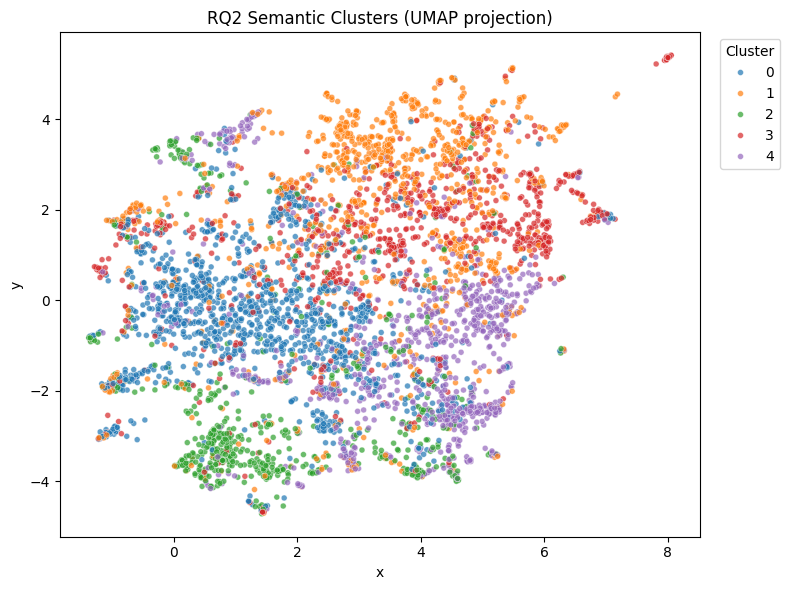

In [19]:
# 2D semantic visualization (UMAP fallback to PCA)
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=SEED)
    emb_2d = reducer.fit_transform(embeddings)
    reducer_name = "UMAP"
except Exception:
    from sklearn.decomposition import PCA
    reducer = PCA(n_components=2, random_state=SEED)
    emb_2d = reducer.fit_transform(embeddings)
    reducer_name = "PCA"

plot_df = pd.DataFrame({
    "x": emb_2d[:, 0],
    "y": emb_2d[:, 1],
    "semantic_cluster": work_df["semantic_cluster"].values,
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df.sample(min(5000, len(plot_df)), random_state=SEED), x="x", y="y", hue="semantic_cluster", s=18, alpha=0.7, palette="tab10")
plt.title(f"RQ2 Semantic Clusters ({reducer_name} projection)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_semantic_scatter.png", dpi=150)
plt.show()

In [20]:
# --------- Final comparison table ---------
comparison = pd.DataFrame([
    {
        "track": "TF-IDF + KMeans",
        "k": TFIDF_K,
        "silhouette": float(silhouette_score(X_tfidf, work_df["tfidf_cluster"])),
        "n_rows": int(len(work_df)),
    },
    {
        "track": "Semantic Embeddings + KMeans",
        "k": SEMANTIC_K,
        "silhouette": float(semantic_silhouette),
        "n_rows": int(len(work_df)),
    },
])
comparison.to_csv(OUTPUT_DIR / "rq2_comparison_table.csv", index=False)
comparison

,track,k,silhouette,n_rows
0,TF-IDF + KMeans,5,0.003760,9998
1,Semantic Embeddings + KMeans,5,0.024115,9998


## Report Notes

Use these files in report/slides:
- `rq2_outputs/rq2_comparison_table.csv` for method comparison.
- `rq2_outputs/rq2_tfidf_top_terms.csv` and `rq2_outputs/rq2_semantic_top_terms.csv` for cluster interpretation.
- `rq2_outputs/rq2_semantic_scatter.png` for visualization.

Recommended narrative: compare interpretability (TF-IDF clusters) vs semantic cohesion (embedding clusters), and discuss practical marketing insights from top terms.

## Cluster Interpretation (Grading-Critical)

For each semantic cluster, provide:
- **Cluster name**
- **Meaning / insight**
- **Business action**

This section creates an editable interpretation table you can finalize before submission.

In [21]:
# --------- Build interpretation table (semantic clusters) ---------
interp_df = cluster_summary_sem.merge(
    semantic_top_terms.rename(columns={"cluster": "semantic_cluster"}),
    on="semantic_cluster",
    how="left",
)

interp_df = interp_df.sort_values("n_reviews", ascending=False).reset_index(drop=True)
interp_df["importance_rank"] = np.arange(1, len(interp_df) + 1)

# Auto-draft fields (edit these manually for your final submission wording)
interp_df["cluster_name"] = interp_df["top_terms"].fillna("").apply(
    lambda s: " / ".join([t.strip() for t in str(s).split(",")[:2]]) if str(s).strip() else "General Segment"
)
interp_df["insight"] = interp_df.apply(
    lambda r: f"Reviews in this cluster frequently mention: {str(r['top_terms']).split(',')[0:4]}",
    axis=1,
)
interp_df["business_action"] = (
    "Create targeted messaging and product-positioning campaigns for this segment, then validate with A/B tests."
)

interp_cols = [
    "importance_rank",
    "semantic_cluster",
    "cluster_name",
    "n_reviews",
    "unique_products",
    "top_terms",
    "insight",
    "business_action",
]

interp_df = interp_df[interp_cols]
interp_df.to_csv(OUTPUT_DIR / "rq2_semantic_cluster_interpretation.csv", index=False)
interp_df

,importance_rank,semantic_cluster,cluster_name,n_reviews,unique_products,top_terms,insight,business_action
0,1,0,use / work,2696,2544,"use, work, one, great, like, get, good, bike, ...",Reviews in this cluster frequently mention: ['...,Create targeted messaging and product-position...
1,2,1,love / great,2157,2086,"love, great, good, like, look, gift, perfect, ...",Reviews in this cluster frequently mention: ['...,Create targeted messaging and product-position...
2,3,4,fit / great,1973,1863,"fit, great, size, bag, perfect, like, comfort,...",Reviews in this cluster frequently mention: ['...,Create targeted messaging and product-position...
3,4,3,great / work,1883,1783,"great, work, qualiti, use, easi, product, good...",Reviews in this cluster frequently mention: ['...,Create targeted messaging and product-position...
4,5,2,use / water,1289,1173,"use, water, bottl, great, one, work, like, get...",Reviews in this cluster frequently mention: ['...,Create targeted messaging and product-position...


In [22]:
# --------- One example review per semantic cluster ---------
example_rows = []
for cid in sorted(work_df["semantic_cluster"].unique()):
    sub = work_df[work_df["semantic_cluster"] == cid].copy()
    if len(sub) == 0:
        continue
    # Choose a representative review with medium length to avoid noisy extremes
    sub["_len"] = sub[text_col].astype(str).str.len()
    sub = sub.sort_values("_len")
    row = sub.iloc[len(sub) // 2]
    example_rows.append({
        "semantic_cluster": int(cid),
        "example_review": str(row[text_col])[:500],
        "rating": row["rating"] if "rating" in row.index else np.nan,
    })

cluster_examples_df = pd.DataFrame(example_rows)
cluster_examples_df.to_csv(OUTPUT_DIR / "rq2_semantic_cluster_examples.csv", index=False)
cluster_examples_df

,semantic_cluster,example_review,rating
0,0,built sturdi expect plate could fit onto one h...,4.0
1,1,nice far could better belt,5.0
2,2,love brand far product purchas amazon well cup...,5.0
3,3,dont good review read purchas pay purchhas better,2.0
4,4,perfect would nice came case draw string somet...,5.0


In [23]:
# --------- Explicit answer to RQ2 question ---------
# Edit wording if needed after reviewing interpretation table.

top_cluster = interp_df.iloc[0]
rq2_answer = (
    "Clustering reveals actionable insights for marketing strategy. "
    "The highest-impact segment (by cluster size) is represented by terms such as "
    f"{', '.join(str(top_cluster['top_terms']).split(',')[:3])}. "
    "Across clusters, the patterns indicate customer preferences and pain points that can guide "
    "audience targeting, product messaging, and prioritization of product improvements."
)

print(rq2_answer)

with open(OUTPUT_DIR / "rq2_final_answer.txt", "w", encoding="utf-8") as f:
    f.write(rq2_answer + "\n")

print("Saved:", OUTPUT_DIR / "rq2_final_answer.txt")

Clustering reveals actionable insights for marketing strategy. The highest-impact segment (by cluster size) is represented by terms such as use,  work,  one. Across clusters, the patterns indicate customer preferences and pain points that can guide audience targeting, product messaging, and prioritization of product improvements.
Saved: /Users/jainesh/Downloads/Deep Learning/6165 group/rq2_outputs/rq2_final_answer.txt
